# L4a Advanced: First-Passage Exit Rules

In the L4a lecture, we evaluated a trade at a scheduled sale time. What changes if we sell earlier when the price reaches a take-profit or stop-loss boundary? Checking only the final price can miss an exit that should have occurred earlier—for example, when the price reaches our profit target and then falls back below it.

> __Learning Objectives__
>
> By the end of this example, you will be able to:
>
> * **Define a monitored exit rule.** Specify take-profit and stop-loss boundaries and explain when a position exits as we check the price after each lattice step.
> * **Compute probabilities of the first exit.** Calculate the probability of reaching each boundary first, or reaching neither during the holding period. We call the first time the price reaches an exit boundary its *first-passage time*.
> * **Compare monitored and terminal-only rules.** Use price paths to explain how checking only the final price can miss an earlier exit, even when different paths finish at the same price.

In this example, we check the price after each binomial lattice step. We will calculate the probability of reaching each boundary first, or reaching neither during the chosen holding period. We will develop the probability calculation before implementing it, then compare these monitored exits with a terminal-only rule.

Let's get started!

___

## Setup, Data, and Prerequisites

First, we load the local [`Include.jl`](Include.jl) setup file and its required packages.

> __Include:__ [The include(...) function](https://docs.julialang.org/en/v1/base/base/#include) evaluates the setup file in the notebook's global scope. This file activates the course project and loads the packages used here.

Let's set up our code environment:


In [1]:
include(joinpath(@__DIR__, "Include.jl")); # load the local notebook setup

  Activating 

project at `~/Desktop/julia_work/CHEME-5660-CourseRepository-Fall-2026`


See the [Julia documentation](https://docs.julialang.org/en/v1/), [DataFrames.jl documentation](https://dataframes.juliadata.org/stable/), [Distributions.jl documentation](https://juliastats.org/Distributions.jl/stable/), and [Plots.jl documentation](https://docs.juliaplots.org/stable/) for the functions and types used here.


In [2]:
default(
    fontfamily = "Helvetica",
    framestyle = :box,
    background_color = :gray97,
    background_color_outside = :white,
    legend_background_color = nothing,
    linewidth = 2,
);

___

## Task 1: Define the monitored exit rule

In this task, we specify when to sell our shares: when the price reaches our take-profit boundary or falls to our stop-loss boundary.

Suppose we purchase shares at price $S_0$. We use the binomial model from the lecture: each step independently multiplies the price by $u$ with probability $p$, or by $d$ with probability $1-p$. These factors and probabilities remain fixed. After $j$ steps containing $k$ up moves, the price is:

$$
S_{j,k}=S_0u^kd^{j-k},
\qquad k=0,1,\ldots,j.
$$

We choose a lower stop-loss boundary $L$ and an upper take-profit boundary $U$, with $L<S_0<U$. After each step, we check any position that remains open:

- If $S_{j,k}\ge U$, sell because the take-profit boundary has been reached.
- If $S_{j,k}\le L$, sell because the stop-loss boundary has been reached.
- Otherwise, keep the position open and continue to the next step.

We also sell when the price equals either boundary exactly. Once we sell, we stop monitoring that position. If neither boundary has been reached after $N$ steps, we record the position as still open.

Let's choose illustrative prices, factors, and an up-move probability for this calculation.


In [3]:
# Specify the binomial price process and absorbing barriers -
S₀ = 100.0 # initial price (USD/share)
u = 1.06   # one-step up factor
d = 0.97   # one-step down factor
p = 0.55   # real-world up probability
N = 12     # monitored lattice steps
L = 90.0   # absorbing stop-loss boundary (USD/share)
U = 115.0  # absorbing take-profit boundary (USD/share)

@assert 0 < d < u
@assert 0 < p < 1
@assert L < S₀ < U
(S₀=S₀, u=u, d=d, p=p, steps=N, stop_loss=L, take_profit=U)

(S₀ = 100.0, u = 1.06, d = 0.97, p = 0.55, steps = 12, stop_loss = 90.0, take_profit = 115.0)

### Why can a terminal check miss an exit?

Using our illustrative values $S_0=100$, $u=1.06$, $d=0.97$, $L=90$, and $U=115$, consider two five-step price paths:

| Moves | Step 0 | Step 1 | Step 2 | Step 3 | Step 4 | Step 5 |
|---|---:|---:|---:|---:|---:|---:|
| Up, up, up, down, down | 100.00 | 106.00 | 112.36 | **119.10** | 115.53 | 112.06 |
| Down, down, up, up, up | 100.00 | 97.00 | 94.09 | 99.74 | 105.72 | 112.06 |

Both stock-price paths finish at the same price because they contain three up moves and two down moves. But their exit histories differ:

- On the first path, we sell at step 3 because the price exceeds 115. The later prices describe how the stock moves after we have sold.
- On the second path, neither boundary is reached during these five steps, so our position remains open.

Checking only the price at step 5 would miss the first path's earlier take-profit exit. Our calculation therefore needs to track which positions remain open as we move through the lattice.


___

## Task 2: Calculate the probabilities of the first exit

In this task, we calculate the probability of selling at the take-profit boundary first, selling at the stop-loss boundary first, or still holding the shares after $N$ steps.

We call a position **open** while we still hold the shares: neither exit boundary has been reached, so we have not sold. Once we sell, the position is **closed**. At each lattice step, we check whether the positions still open should be sold or carried forward to the next step.

Let $a_{j,k}$ be the probability that, after checking the boundaries at step $j$, we have observed $k$ up moves **and the position is still open**. Any path that has already triggered an exit contributes nothing to this probability.

Initially, the price lies between the boundaries, so the position is open with certainty:

$$
a_{0,0}=1.
$$

At a later step, adding these probabilities across the nodes gives:

$$
\sum_{k=0}^{j}a_{j,k}
=
\mathbb P(\text{position remains open after step }j).
$$

This sum can be less than one because some positions may already have exited. Let's now work out how to update these probabilities from one step to the next.


### Move to the next lattice step

Consider a node at step 3 with two up moves. There are two ways to arrive at this node:

- We had one up move after step 2, then move up. This contributes $p\,a_{2,1}$.
- We had two up moves after step 2, then move down. This contributes $(1-p)a_{2,2}$.

Adding these contributions gives:

$$
b_{3,2}=p\,a_{2,1}+(1-p)a_{2,2}.
$$

Both contributions include only positions we were still holding after step 2. The quantity $b_{3,2}$ is their combined probability **before checking whether the new price requires us to sell**.

The same reasoning applies at every step. To arrive with $k$ up moves after $j$ steps, we either move up from a node with $k-1$ up moves or move down from a node with $k$ up moves. Thus:

$$
b_{j,k}
=
\underbrace{p\,a_{j-1,k-1}}_{\text{arrive by an up move}}
+
\underbrace{(1-p)a_{j-1,k}}_{\text{arrive by a down move}},
\qquad k=0,\ldots,j.
$$

At the edges of the lattice, only one contribution exists: $k=0$ requires a down move, while $k=j$ requires an up move. We set the missing contribution to zero.

The probability $b_{j,k}$ is calculated before checking the new price. Let's now determine whether we continue holding the shares or sell.


### Check the exit boundaries

We now compare the price $S_{j,k}$ with our exit boundaries. If the price lies strictly between $L$ and $U$, we keep holding the shares. Otherwise, we sell. The probability that the position remains open at this node is therefore:

$$
a_{j,k}=\begin{cases}
b_{j,k}, & L<S_{j,k}<U,\\
0, & S_{j,k}\le L\ \text{or}\ S_{j,k}\ge U.
\end{cases}
$$

Setting $a_{j,k}=0$ means that no position arriving at this node remains open. The arrival probability $b_{j,k}$ is still recorded:

- If the price is at or below $L$, it contributes to the probability of a stop-loss exit at step $j$.
- If the price is at or above $U$, it contributes to the probability of a take-profit exit at step $j$.

Only the open-position probabilities $a_{j,k}$ are carried forward to the next step. This prevents us from counting another exit after the shares have already been sold.


### Calculate the exit probabilities at step $j$

Several nodes at the same step may trigger a sale. To calculate the probability of each type of exit, we add the arrival probabilities at the corresponding nodes.

Let $q_j^L$ be the probability of a stop-loss exit **at step $j$**, and $q_j^U$ the probability of a take-profit exit at that step:

$$
q_j^L=\sum_{\substack{0\le k\le j\\S_{j,k}\le L}}b_{j,k},
\qquad
q_j^U=\sum_{\substack{0\le k\le j\\S_{j,k}\ge U}}b_{j,k}.
$$

The first sum includes nodes at or below the stop-loss boundary; the second includes nodes at or above the take-profit boundary. If no node satisfies a condition, its sum is zero.

These are probabilities of **new exits at this step**. Positions sold earlier are already excluded from $b_{j,k}$, so they cannot be counted again.


### Account for all three outcomes

To find the probability of a stop-loss exit by step $N$, we add $q_j^L$ over steps $1,\ldots,N$. Similarly, adding $q_j^U$ gives the probability of a take-profit exit by step $N$. We can add across steps because each position is sold only once.

After $N$ steps, we have either sold at one of the two boundaries or still hold the shares. These three outcomes account for every possible price path, so:

$$
\underbrace{\sum_{j=1}^{N}q_j^L}_{\text{stop-loss exit by }N}
+
\underbrace{\sum_{j=1}^{N}q_j^U}_{\text{take-profit exit by }N}
+
\underbrace{\sum_{k=0}^{N}a_{N,k}}_{\text{still holding after }N}
=1.
$$

This gives us a useful check on the calculation. We will verify the same probability balance after every lattice step, allowing for small floating-point rounding differences.

We now have the equations needed to implement the monitored exit rule.


### Implement the probability calculation

Let's implement these equations using two helper functions:

- [The price_at(...) function](docs/first-passage-functions.md#price_at) calculates $S_{j,k}$ from the initial price, price-change factors, step number, and up-move count.
- [The first_passage_binomial(...) function](docs/first-passage-functions.md#first_passage_binomial) moves through the lattice, records new exits at each step, and carries forward the probabilities of positions we still hold. It also checks that the probabilities of the three outcomes sum to one.

The array `alive` stores the open-position probabilities at the current step. Because Julia arrays start at index 1, `alive[k+1]` corresponds to $a_{j,k}$.


In [4]:
price_at(S₀::Real, u::Real, d::Real, j::Int, k::Int) = S₀*u^k*d^(j-k)

function first_passage_binomial(S₀::Real, u::Real, d::Real, p::Real, N::Int; lower::Real, upper::Real)
    @assert 0 < d < u
    @assert 0 <= p <= 1
    @assert lower < S₀ < upper
    @assert N >= 1

    # alive[k+1] stores open probability at mathematical up-count k; Julia arrays start at 1.
    alive = [1.0]
    cumulative_lower = 0.0
    cumulative_upper = 0.0
    rows = NamedTuple[(
        step=0, hit_lower_at_step=0.0, hit_upper_at_step=0.0,
        cumulative_lower=0.0, cumulative_upper=0.0, open_probability=1.0,
    )]

    for j ∈ 1:N
        next_alive = zeros(Float64, j + 1) # up counts k=0,...,j map to positions k+1
        lower_at_step = 0.0
        upper_at_step = 0.0

        # Propagate only mass that has not already reached either absorbing boundary.
        for k_previous ∈ 0:(j-1)
            open_mass = alive[k_previous + 1]
            for (k_new, branch_probability) ∈ ((k_previous, 1-p), (k_previous + 1, p))
                branch_mass = open_mass*branch_probability
                destination_price = price_at(S₀, u, d, j, k_new)
                if destination_price <= lower
                    lower_at_step += branch_mass # absorb newly detected stop-loss mass
                elseif destination_price >= upper
                    upper_at_step += branch_mass # absorb newly detected take-profit mass
                else
                    next_alive[k_new + 1] += branch_mass # retain open mass at Julia position k_new+1
                end
            end
        end

        cumulative_lower += lower_at_step
        cumulative_upper += upper_at_step
        open_probability = sum(next_alive)
        @assert isapprox(cumulative_lower + cumulative_upper + open_probability, 1.0; atol=1e-12)

        push!(rows, (
            step=j, hit_lower_at_step=lower_at_step, hit_upper_at_step=upper_at_step,
            cumulative_lower=cumulative_lower, cumulative_upper=cumulative_upper,
            open_probability=open_probability,
        ))
        alive = next_alive
    end

    return (
        summary=DataFrame(rows), alive=alive,
        hit_lower=cumulative_lower, hit_upper=cumulative_upper, still_open=sum(alive),
    )
end

first_passage_binomial (generic function with 1 method)

Let's run the calculation using our chosen parameters and store the result in `result`. Its `summary` table shows how the exit probabilities develop over time:

- **New exits:** the probabilities of selling at each boundary at that step.
- **Cumulative exits:** the probabilities of having sold at each boundary by that step.
- **Still holding:** the probability that neither boundary has been reached.

The row for step zero gives the initial condition: we hold the shares with certainty, and no exits have occurred.


In [5]:
result = first_passage_binomial(S₀, u, d, p, N; lower=L, upper=U)

let
    # Use readable headings and round only the displayed probabilities.
    table = rename(copy(result.summary), ["Step", "New stop loss", "New take profit",
        "Stop loss by step", "Take profit by step", "Still holding"])
    pretty_table(table;
        display_size=(0, 0),
        formatters=[fmt__printf("%.6f", [2, 3, 4, 5, 6])],
        table_format=TextTableFormat(borders=text_table_borders__compact))
end


 ----------------------------------------------------------------------------------------------------
   Step   New stop loss   New take profit   Stop loss by step   Take profit by step   Still holding 
  Int64         Float64           Float64             Float64               Float64         Float64 
 ----------------------------------------------------------------------------------------------------
      0        0.000000          0.000000            0.000000              0.000000        1.000000
      1        0.000000          0.000000            0.000000              0.000000        1.000000
      2        0.000000          0.000000            0.000000              0.000000        1.000000
      3        0.000000          0.166375            0.000000              0.166375        0.833625
      4        0.041006          0.224606            0.041006              0.390981        0.568012
      5        0.000000          0.000000            0.041006              0.390981        0.5

Let's summarize the outcomes after $N$ steps. The table below gives the probability of selling at the take-profit boundary first, selling at the stop-loss boundary first, or still holding the shares. The exit probabilities include all sales from step 1 through step $N$.


In [6]:
outcome_table = DataFrame(
    outcome = ["Take profit first", "Stop loss first", "Still holding after $(N) steps"],
    probability = [result.hit_upper, result.hit_lower, result.still_open],
)
@assert isapprox(sum(outcome_table.probability), 1.0; atol=1e-12)
let
    # Format the summary without changing the stored probabilities.
    table = rename(copy(outcome_table), ["Outcome", "Probability"])
    pretty_table(table;
        display_size=(0, 0),
        formatters=[fmt__printf("%.6f", [2])],
        table_format=TextTableFormat(borders=text_table_borders__compact))
end


 ---------------------------------------------
                       Outcome   Probability 
                        String       Float64 
 ---------------------------------------------
             Take profit first      0.788360
               Stop loss first      0.068430
  Still holding after 12 steps      0.143210
 ---------------------------------------------


Let's plot how the three outcome probabilities change as we monitor the position. The green and red curves show the probabilities of having sold at the take-profit and stop-loss boundaries, respectively. The blue curve shows the probability of still holding the shares.

As more positions exit, the cumulative exit probabilities can increase, while the probability of still holding cannot increase. At every step, the three probabilities sum to one.


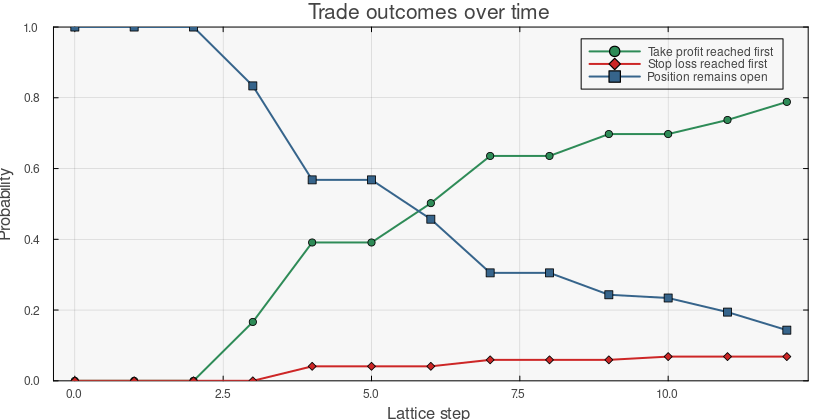

In [7]:
plot(
    result.summary.step, result.summary.cumulative_upper;
    marker=:circle, color=:seagreen4, label="Take profit reached first",
    xlabel="Lattice step", ylabel="Probability",
    title="Trade outcomes over time",
    ylim=(0, 1), size=(820, 420),
)
plot!(result.summary.step, result.summary.cumulative_lower;
    marker=:diamond, color=:firebrick3, label="Stop loss reached first")
plot!(result.summary.step, result.summary.open_probability;
    marker=:square, color=:steelblue4, label="Position remains open")

___

## Task 3: Compare monitored and terminal-only exits

In this task, we compare two ways of checking our take-profit boundary. We temporarily disable the stop-loss so that an earlier stop-loss sale cannot prevent a later take-profit exit. We keep the other model parameters fixed.

We ask two questions:

- **Terminal-only:** What is the probability that the price is at or above $U$ at step $N$?
- **Monitored:** What is the probability that the price reaches or exceeds $U$ at any step from 1 through $N$?

Every stock-price path that finishes at or above $U$ has reached that boundary by step $N$, even if it first reaches it at the final step. Other paths reach $U$ earlier and then fall below it. Thus, the monitored probability must be at least as large as the terminal-only probability.

This comparison assumes no stop-loss exit. With both boundaries active, we might sell at the stop-loss before the stock later reaches the take-profit boundary.


### Calculate the terminal-only probability

Let $K_N$ be the number of up moves after $N$ steps. Under our independent-move model, $K_N$ has a binomial distribution. The probability of $k$ up moves is:

$$
\mathbb P(K_N=k)=\binom Nk p^k(1-p)^{N-k}.
$$

Each count gives the terminal price $S_{N,k}=S_0u^kd^{N-k}$. We check which prices are at or above $U$, then add their probabilities:

$$
\mathbb P(S_{N,K_N}\ge U)
=
\sum_{\substack{0\le k\le N\\S_{N,k}\ge U}}
\binom Nk p^k(1-p)^{N-k}.
$$

This calculation includes every path with a qualifying final price, regardless of whether it reached the boundary earlier. If no terminal node reaches $U$, the probability is zero.


Let's calculate both probabilities. [The terminal_upper_probability(...) function](docs/first-passage-functions.md#terminal_upper_probability) evaluates the terminal-only sum. We store its result in `terminal_probability`.

For the monitored calculation, we reuse [the first_passage_binomial(...) function](docs/first-passage-functions.md#first_passage_binomial) with `lower=0.0`. Prices in this model remain positive, so they cannot reach that lower boundary. This disables the stop-loss while keeping the take-profit boundary unchanged.

The result `upper_only.hit_upper` gives the probability of reaching the take-profit boundary by step $N$. We place the two probabilities side by side in the comparison table.


In [8]:
function terminal_upper_probability(S₀::Real, u::Real, d::Real, p::Real, N::Int, upper::Real)
    distribution = Binomial(N, p)
    return sum(
        (pdf(distribution, k) for k in 0:N
            if price_at(S₀, u, d, N, k) >= upper);
        init=0.0,
    )
end

terminal_probability = terminal_upper_probability(S₀, u, d, p, N, U)
upper_only = first_passage_binomial(S₀, u, d, p, N; lower=0.0, upper=U)
comparison = DataFrame(
    rule = ["Terminal price at or above U", "Upper boundary reached by N; no stop loss"],
    probability = [terminal_probability, upper_only.hit_upper],
)
@assert upper_only.hit_upper + 1e-12 >= terminal_probability
let
    # Keep both rules on the same probability scale.
    table = rename(copy(comparison), ["Rule", "Probability"])
    pretty_table(table;
        display_size=(0, 0),
        formatters=[fmt__printf("%.6f", [2])],
        table_format=TextTableFormat(borders=text_table_borders__compact))
end


 ----------------------------------------------------------
                                       Rule   Probability 
                                     String       Float64 
 ----------------------------------------------------------
               Terminal price at or above U      0.739315
  Upper boundary reached by N; no stop loss      0.798494
 ----------------------------------------------------------


__What does the difference tell us?__ Subtracting the terminal-only probability from the monitored probability gives the probability that the price reaches the take-profit boundary during the holding period but finishes below it. These are the earlier take-profit exits that checking only the final price would miss.


___

## Summary

This notebook replaced a terminal-node calculation with an absorbing probability recursion whose state distinguishes positions that remain open from positions that have already crossed a boundary.

> __Key Takeaways:__
>
> - **Terminal and monitored rules answer different questions:** Ending above a boundary is not the same event as reaching that boundary at any earlier time.
> - **Absorption prevents double counting:** Once probability mass exits through one boundary, it is not propagated again.
> - **Path-dependent rules require exit status:** A terminal price node alone does not reveal whether a take-profit or stop-loss boundary was crossed earlier.

The same recursion extends to time-dependent boundaries and other discrete monitored-exit rules.

___

## Disclaimer and Risks

__This content is offered solely for training and informational purposes__. No offer or solicitation to buy or sell securities or derivative products, or any investment or trading advice or strategy, is made, given, or endorsed by the teaching team.

__Trading involves risk__. Carefully review your financial situation before investing in securities, futures contracts, options, or commodity interests. Past performance, whether actual or indicated by historical tests of strategies, is no guarantee of future performance or success. Trading is generally inappropriate for someone with limited resources, investment or trading experience, or a low-risk tolerance. Only risk capital that is not required for living expenses should be used.

__You are fully responsible for any investment or trading decisions you make__. Such decisions should be based solely on evaluating your financial circumstances, investment or trading objectives, risk tolerance, and liquidity needs.

Boundary probabilities depend on the lattice parameters and on the assumed monitoring and execution rules. A real stop or limit order need not execute at its trigger price.
